In [1]:
# --------------------------------------------------
# IMPORT REQUIRED LIBRARIES
# --------------------------------------------------

# Import pandas for working with datasets
import pandas as pd

# Import matplotlib for charts and graphs
import matplotlib.pyplot as plt

# Import seaborn for data visualization
import seaborn as sns

# Import numpy for numerical operations
import numpy as np

In [2]:
# --------------------------------------------------
# READ THE AVOCADO DATASET
# --------------------------------------------------

# Load the avocado dataset into a DataFrame
avocado_info = pd.read_csv(
    r'D:\MiniForge\Ex_Files_Intro_to_Data_Science\Ex_Files_Intro_to_Data_Science\Exercise Files\avocado_info.csv'
)

In [4]:
# --------------------------------------------------
# DISPLAY THE FIRST 50 ROWS
# --------------------------------------------------

# Display the first 50 rows of the dataset
avocado_info.head(50)

,Growth Duration,Fertilizer
0,98,True
1,108,False
2,129,False
3,116,False
4,111,False
5,131,False
6,110,False
7,118,False
8,112,False
9,110,False


In [5]:
# --------------------------------------------------
# DISPLAY THE ENTIRE DATAFRAME
# --------------------------------------------------

# Display the avocado dataset
avocado_info

,Growth Duration,Fertilizer
0,98,True
1,108,False
2,129,False
3,116,False
4,111,False
...,...,...
1169,125,False
1170,136,True
1171,125,False
1172,108,False


In [6]:
# --------------------------------------------------
# CHECK THE COLUMN NAMES
# --------------------------------------------------

# Display all column names in the dataset
avocado_info.columns

Index(['Growth Duration', 'Fertilizer'], dtype='str')

In [7]:
# --------------------------------------------------
# DISPLAY BASIC INFORMATION ABOUT THE DATASET
# --------------------------------------------------

# Display information about rows, columns, and data types
avocado_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Growth Duration  1174 non-null   int64
 1   Fertilizer       1174 non-null   bool 
dtypes: bool(1), int64(1)
memory usage: 10.4 KB


In [8]:
# --------------------------------------------------
# DISPLAY SUMMARY STATISTICS
# --------------------------------------------------

# Display descriptive statistics for numerical columns
avocado_info.describe()

,Growth Duration
count,1174.000000
mean,119.462521
std,18.328671
min,55.000000
25%,108.000000
50%,120.000000
75%,131.000000
max,176.000000


In [14]:
# Show the exact column names and first rows
print(avocado_info.columns.tolist())
avocado_info.head()

['Growth Duration', 'Fertilizer']


,Growth Duration,Fertilizer
0,98,True
1,108,False
2,129,False
3,116,False
4,111,False


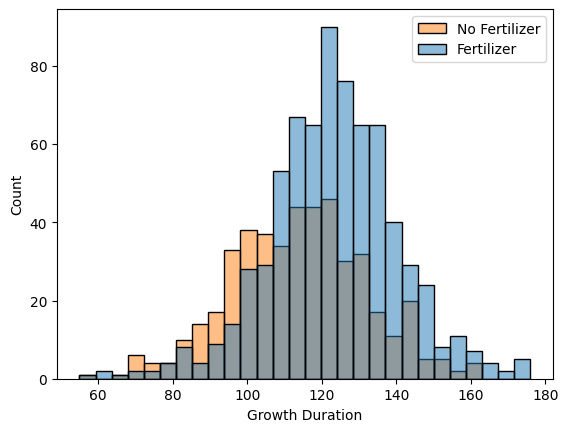

In [15]:
# ------------------------------------------------
# CREATE OVERLAID HISTOGRAMS
# TO COMPARE GROWTH DURATION
# ------------------------------------------------

# Create histograms grouped by fertilizer use
sns.histplot(
    data=avocado_info,
    x='Growth Duration',
    hue='Fertilizer'
)

# Add legend labels
plt.legend(labels=['No Fertilizer', 'Fertilizer'])

# Display the histogram
plt.show()

In [18]:
# --------------------------------------------------
# CALCULATE THE AVERAGE GROWTH DURATION
# FOR TREES THAT RECEIVED FERTILIZER
# --------------------------------------------------

# Create a subset containing fertilized trees
fertilized = avocado_info.loc[
    avocado_info['Fertilizer'] == True,
    :
]

# Calculate the average growth duration
fertilized['Growth Duration'].mean()


np.float64(113.81917211328977)

In [19]:
# --------------------------------------------------
# CALCULATE THE AVERAGE GROWTH DURATION
# FOR TREES WITHOUT FERTILIZER
# --------------------------------------------------

# Create a subset containing trees without fertilizer
not_fertilized = avocado_info.loc[
    avocado_info['Fertilizer'] == False,
    :
]

# Calculate the average growth duration
not_fertilized['Growth Duration'].mean()

np.float64(123.08531468531469)

In [20]:
# --------------------------------------------------
# CREATE A TEST STATISTIC
# --------------------------------------------------

# Calculate:
# Average growth duration with fertilizer
# minus
# Average growth duration without fertilizer

test_statistic = (
    fertilized['Growth Duration'].mean()
    -
    not_fertilized['Growth Duration'].mean()
)

# Display the test statistic
test_statistic

np.float64(-9.266142572024918)

In [21]:
# --------------------------------------------------
# SORT THE DATA BY GROWTH DURATION
# --------------------------------------------------

# Sort the avocado dataset from shortest to longest growth duration
sorted_growth = avocado_info.sort_values(
    'Growth Duration',
    ascending=True
)

# Display the sorted dataset
sorted_growth

,Growth Duration,Fertilizer
323,55,False
865,58,True
35,62,False
66,63,False
1010,65,False
...,...,...
630,173,False
509,174,False
457,174,False
692,174,False


In [22]:
# --------------------------------------------------
# DISPLAY THE TOP 10 FASTEST GROWING TREES
# --------------------------------------------------

# Display the first 10 rows from the sorted dataset
sorted_growth.iloc[0:10]

,Growth Duration,Fertilizer
323,55,False
865,58,True
35,62,False
66,63,False
1010,65,False
1009,65,True
1117,68,True
405,69,True
183,71,True
272,71,False


In [23]:
# --------------------------------------------------
# COUNT HOW MANY TREES USED FERTILIZER
# --------------------------------------------------

# Count fertilizer categories
avocado_info['Fertilizer'].value_counts()

Fertilizer
False    715
True     459
Name: count, dtype: int64

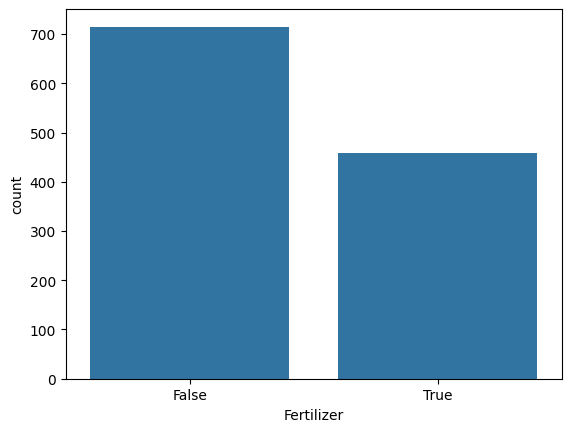

In [24]:
# --------------------------------------------------
# CREATE A BAR CHART OF FERTILIZER COUNTS
# --------------------------------------------------

# Create a count plot for fertilizer usage
sns.countplot(
    x='Fertilizer',
    data=avocado_info
)

# Display the chart
plt.show()

In [25]:
# --------------------------------------------------
# CREATE A PERMUTATION OF GROWTH DURATION
# --------------------------------------------------

# Randomly shuffle all values in the Growth Duration column
permuted_growth = avocado_info['Growth Duration'].sample(
    frac=1
)

# Display the permuted values
permuted_growth

20      115
1022    136
100     126
1142     91
618     142
       ... 
600     115
959     112
742     118
544     112
435     105
Name: Growth Duration, Length: 1174, dtype: int64

In [26]:
# --------------------------------------------------
# RESET THE INDEX OF THE PERMUTED DATA
# --------------------------------------------------

# Reset the index after permutation
permuted_growth = permuted_growth.reset_index()

# Display the permuted data with reset index
permuted_growth

,index,Growth Duration
0,20,115
1,1022,136
2,100,126
3,1142,91
4,618,142
...,...,...
1169,600,115
1170,959,112
1171,742,118
1172,544,112


In [27]:
# --------------------------------------------------
# RESET INDEX AND DROP OLD INDEX COLUMN
# --------------------------------------------------

# Reset index and remove the old shuffled index column
permuted_growth = permuted_growth.reset_index(
    drop=True
)

# Display the cleaned permutation
permuted_growth

,index,Growth Duration
0,20,115
1,1022,136
2,100,126
3,1142,91
4,618,142
...,...,...
1169,600,115
1170,959,112
1171,742,118
1172,544,112


In [28]:
# --------------------------------------------------
# CALCULATE OBSERVED TEST STATISTIC
# --------------------------------------------------

# Calculate:
# Average growth duration with fertilizer
# minus
# Average growth duration without fertilizer

observed_test_stat = (
    fertilized['Growth Duration'].mean()
    -
    not_fertilized['Growth Duration'].mean()
)

# Display the observed test statistic
observed_test_stat

np.float64(-9.266142572024918)

In [35]:
# --------------------------------------------------
# DEFINE A FUNCTION TO CREATE A PERMUTATION
# --------------------------------------------------

def perm(data):

    return data.sample(
        frac = 1
    ).reset_index(
        drop = True
    )

In [30]:
# --------------------------------------------------
# CREATE AN EMPTY ARRAY
# TO STORE SIMULATED TEST STATISTICS
# --------------------------------------------------

# Create an empty NumPy array
sim_test_stat = np.array([])

# Number of permutations
reps = 10000

In [36]:
# --------------------------------------------------
# CREATE AN EMPTY ARRAY
# TO STORE SIMULATED TEST STATISTICS
# --------------------------------------------------

sim_test_stat = np.array([])

# Number of repetitions
reps = 10000

# Repeat permutation process
for i in range(reps):

    # Permute Growth Duration values
    perm_info = perm(
        avocado_info["Growth Duration"]
    )

    # Create a new DataFrame
    df = pd.DataFrame({

        "Permuted Duration": perm_info,

        "Fertilizer": avocado_info["Fertilizer"]

    })

    # Trees with fertilizer
    fertilized = df.loc[
        df["Fertilizer"] == True,
        "Permuted Duration"
    ]

    # Trees without fertilizer
    not_fertilized = df.loc[
        df["Fertilizer"] == False,
        "Permuted Duration"
    ]

    # Compute simulated test statistic
    stat = (
        np.mean(fertilized)
        -
        np.mean(not_fertilized)
    )

    # Store simulated statistic
    sim_test_stat = np.append(
        sim_test_stat,
        stat
    )

In [37]:
# --------------------------------------------------
# DISPLAY SIMULATED TEST STATISTICS
# --------------------------------------------------

sim_test_stat

array([ 1.77325289,  1.89845666, -0.38382924, ..., -0.94903484,
        0.56056493, -0.00464068], shape=(10000,))

In [38]:
# --------------------------------------------------
# CALCULATE THE P-VALUE
# --------------------------------------------------

p_value = (
    np.count_nonzero(
        sim_test_stat <= observed_test_stat
    )
    /
    reps
)

# Display p-value
p_value

np.float64(0.0)

In [39]:
# --------------------------------------------------
# DRAW A CONCLUSION
# --------------------------------------------------

if p_value < 0.05:

    print("Reject the null hypothesis")

    print("There is a statistically significant difference")

else:

    print("Fail to reject the null hypothesis")

    print("There is not enough evidence of a significant difference")

Reject the null hypothesis
There is a statistically significant difference
